# Trajectory-resolved modular response: CPU pilot

This notebook computes two charge responses directly from saved trajectory covariance matrices:

1. the **retarded modular response** following an infinitesimal local charge-phase kick; and
2. the **static modular susceptibility** to a local modular chemical potential.

The inputs are matched legacy hard- and soft-wall runs at $N_x=N_y=20$, with 10 trajectories and complete covariance histories through cycle 40. They use perfect correction, $n_{\rm shell}=1$, $\alpha_1=1$, $\alpha_2=30$, raster-$y$ order, and a maximally mixed initializer. Consequently, this is a method/feasibility pilot rather than a production claim about the redesigned random-pure W1 ensemble.

Every nonlinear modular construction is performed separately for each trajectory and translated half-cylinder cut. Cuts are averaged within a trajectory; they are never counted as independent samples.

## Runtime and CPU allocation

Set `CPU_RANGE` before running. The notebook confines itself to that affinity and uses one BLAS thread per parallel worker.

In [1]:
import os
from pathlib import Path

CPU_RANGE = os.environ.get("MODULAR_RESPONSE_CPU_RANGE", "0-27")
N_WORKERS_REQUESTED = int(os.environ.get("MODULAR_RESPONSE_WORKERS", "14"))

def parse_cpu_range(spec):
    values = set()
    for part in spec.split(","):
        part = part.strip()
        if not part:
            continue
        if "-" in part:
            lo, hi = map(int, part.split("-", 1))
            values.update(range(lo, hi + 1))
        else:
            values.add(int(part))
    return sorted(values)

requested_cpus = set(parse_cpu_range(CPU_RANGE))
available_cpus = set(os.sched_getaffinity(0))
selected_cpus = sorted(requested_cpus & available_cpus)
if not selected_cpus:
    selected_cpus = sorted(available_cpus)
os.sched_setaffinity(0, selected_cpus)

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"

import json
import math
import shutil
import sys
import time
import zipfile
from hashlib import sha256

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from joblib import Parallel, delayed
from scipy.linalg import expm
from threadpoolctl import threadpool_limits

N_WORKERS = max(1, min(N_WORKERS_REQUESTED, len(selected_cpus)))
print({"cpu_range_requested": CPU_RANGE, "cpu_affinity": selected_cpus, "workers": N_WORKERS})

{'cpu_range_requested': '0-27', 'cpu_affinity': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27], 'workers': 14}


## Data and fixed pilot parameters

The two inputs differ only in the wall implementation relevant to this pilot. The third legacy `dw_truncation=True, meas_slab_only=False` history is intentionally excluded.

In [2]:
def locate_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "PROJECT_ADMIN" / "REPO_POLICY.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")

ROOT = locate_repo_root()
PILOT_DIR = ROOT / "notebooks" / "modular_response_cpu_pilot"
CACHE_DIR = PILOT_DIR / "analysis_cache"
OUTPUT_DIR = PILOT_DIR / "outputs"
FIGURE_DIR = PILOT_DIR / "figures"
for directory in (CACHE_DIR, OUTPUT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_FILES = {
    "hard": ROOT / "cache/G_history_samples/N20x20/N20x20_C40_S10_nsh1_DW1_alpha_top1.0_alpha_triv30.0_trial-X_dwtrunc1_init-maxmix_n_a0.5_seq-raster_y_exclNone_ps0_psp0_pc1_mslab1_markov_circuit_n20x20_dwtrunc_convergence_cpu.npz",
    "soft": ROOT / "cache/G_history_samples/N20x20/N20x20_C40_S10_nsh1_DW1_alpha_top1.0_alpha_triv30.0_trial-X_dwtrunc0_init-maxmix_n_a0.5_seq-raster_y_exclNone_ps0_psp0_pc1_mslab0_markov_circuit_n20x20_dwtrunc_convergence_cpu.npz",
}

NX = NY = 20
NY_SUB = NY // 2
DIM = 2 * NX * NY_SUB
SAMPLES = 10
CHECKPOINTS = np.array([21, 25, 29, 33, 37, 40], dtype=int)
Y0_VALUES = np.arange(NY, dtype=int)
WALL_X = np.array([5, 15], dtype=int)
ENDPOINTS = np.array([0, NY_SUB - 1], dtype=int)
SOURCE_LABELS = np.array([f"wall{w}_y{y}" for w in range(2) for y in (0, NY_SUB - 1)])
MODULAR_TIMES = np.arange(0.0, 4.0 + 0.025, 0.05)
CLIP_EPS = np.array([1e-8, 1e-10, 1e-12])
PRIMARY_EPS_INDEX = 1
FIT_WINDOW = (0.1, 0.8)
BOOTSTRAP_REPS = 5000
BOOTSTRAP_SEED = 20260826

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["CMU Sans Serif", "DejaVu Sans"],
    "font.size": 8,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

print({
    "repo": str(ROOT), "checkpoints": CHECKPOINTS.tolist(), "translated_cuts": len(Y0_VALUES),
    "sources": SOURCE_LABELS.tolist(), "modular_time_points": len(MODULAR_TIMES),
})

{'repo': '/home/abhuiyan/class_A_fermionic_adaptive_circuit', 'checkpoints': [21, 25, 29, 33, 37, 40], 'translated_cuts': 20, 'sources': ['wall0_y0', 'wall0_y9', 'wall1_y0', 'wall1_y9'], 'modular_time_points': 81}


## Estimators

For each translated half-cylinder $A(y_0)=[0,N_x)\times[y_0,y_0+N_y/2)$, the repository's centered covariance convention gives
$$
C_A=\frac{\mathbf 1_A+G_A}{2},\qquad
h_A=\log\frac{\mathbf 1_A-C_A}{C_A}.
$$

For a local two-orbital charge projector $P_0$, the retarded tangent is
$$
X(0)=-i[P_0,C_A],\qquad
X(\tau)=e^{-ih_A\tau}X(0)e^{ih_A\tau},\qquad
\chi^R(r,\tau)=\operatorname{tr}[P_rX(\tau)].
$$
It is a signed, number-conserving response—not a probability distribution.

For the static response, use $h_\lambda=h_A-\lambda P_0$ and
$$
\chi^{\rm stat}(r)=\left.\frac{\partial}{\partial\lambda}
\operatorname{tr}\left[P_r(\mathbf 1_A+e^{h_\lambda})^{-1}\right]\right|_{\lambda=0}.
$$
The implementation evaluates the exact Fréchet derivative in the modular eigenbasis.

### Derivation in the single-particle eigenbasis

Diagonalize the restricted correlation matrix as
$$
C_A=U\,\operatorname{diag}(\nu_a)U^\dagger,
\qquad 0\leq\nu_a\leq1.
$$
For a number-conserving Gaussian density operator
$$
\hat\rho_A=Z_A^{-1}\exp\!\left[-\sum_{ij}(h_A)_{ij}
\hat c_i^\dagger\hat c_j\right],
$$
the Fermi relation $C_A=(\mathbf 1_A+e^{h_A})^{-1}$ gives
$$
h_A=U\,\operatorname{diag}(\varepsilon_a)U^\dagger,
\qquad
\varepsilon_a=\log\frac{1-\nu_a}{\nu_a}.
$$
Numerically, $\nu_a$ is clipped to $[\epsilon,1-\epsilon]$ before taking this logarithm. The calculation is repeated at three values of $\epsilon$ because modes exponentially close to 0 or 1 generate very large modular energies.

For the retarded response, apply the local many-body unitary
$$
\hat U_\lambda=e^{-i\lambda\hat N_0},
\qquad
\hat N_0=\sum_{\mu\in\{A,B\}}
\hat c_{0,\mu}^\dagger\hat c_{0,\mu},
$$
whose single-particle generator is the two-orbital projector $P_0$. To first order,
$$
C_\lambda(0)=e^{-i\lambda P_0}C_Ae^{i\lambda P_0}
=C_A+\lambda X(0)+O(\lambda^2),
\qquad X(0)=-i[P_0,C_A].
$$
Because $[h_A,C_A]=0$, modular-time evolution yields
$$
X(\tau)=e^{-ih_A\tau}X(0)e^{ih_A\tau}.
$$
Writing $\widetilde P_0=U^\dagger P_0U$, its matrix elements are
$$
\widetilde X_{ab}(\tau)
=-i(\nu_b-\nu_a)(\widetilde P_0)_{ab}
e^{-i(\varepsilon_a-\varepsilon_b)\tau}.
$$
The local response is the orbital trace
$$
\chi^R(\boldsymbol r,\tau)
=\operatorname{tr}[P_{\boldsymbol r}X(\tau)].
$$
Its spatial sum vanishes because $\operatorname{tr}X(\tau)=0$. Therefore the notebook characterizes propagation with the signed wall dipole $M_y(\tau)=\sum_{\boldsymbol r\in w}(y-y_0)\chi^R(\boldsymbol r,\tau)$, rather than an ill-defined normalized center of mass.

For the static response, let $f(x)=(1+e^x)^{-1}$ and perturb $h_A\mapsto h_A-\lambda P_0$. The Fréchet derivative of $f$ gives
$$
(\delta C_A)_{ab}
=-f^{[1]}(\varepsilon_a,\varepsilon_b)(\widetilde P_0)_{ab},
$$
where
$$
f^{[1]}(x,y)=
\begin{cases}
\dfrac{f(x)-f(y)}{x-y},&x\neq y,\\[6pt]
f'(x)=-f(x)[1-f(x)],&x=y.
\end{cases}
$$
Transforming $\delta C_A$ back to the local basis gives
$\chi^{\rm stat}(\boldsymbol r)=\operatorname{tr}[P_{\boldsymbol r}\delta C_A]$.
The sign convention $h_A-\lambda P_0$ means positive $\lambda$ attracts modular charge.

Finally, the map $C_A\mapsto h_A$ is nonlinear. Consequently,
$$
\frac1{N_y}\sum_{y_0}\chi[C_A(y_0)]
\neq
\chi\!\left[\frac1{N_y}\sum_{y_0}C_A(y_0)\right]
$$
in general. This notebook uses the left-hand ordering separately for every trajectory, then performs trajectory statistics.

In [3]:
def file_sha256(path, chunk=8 * 1024 * 1024):
    digest = sha256()
    with open(path, "rb") as handle:
        while data := handle.read(chunk):
            digest.update(data)
    return digest.hexdigest()

def read_run_config(path):
    with np.load(path, allow_pickle=False) as archive:
        return json.loads(str(archive["run_config"]))

def extract_history(path, label):
    target = CACHE_DIR / f"{label}_G_hist.npy"
    if target.exists():
        array = np.load(target, mmap_mode="r", allow_pickle=False)
        if array.shape == (SAMPLES, 41, 2 * NX * NY, 2 * NX * NY) and array.dtype == np.complex128:
            return target
        raise ValueError(f"Stale extracted cache has unexpected schema: {target}, {array.shape}, {array.dtype}")
    temporary = target.with_suffix(".npy.partial")
    if temporary.exists():
        temporary.unlink()
    with zipfile.ZipFile(path) as archive, archive.open("G_hist.npy") as source, open(temporary, "wb") as sink:
        shutil.copyfileobj(source, sink, length=16 * 1024 * 1024)
    temporary.replace(target)
    array = np.load(target, mmap_mode="r", allow_pickle=False)
    if array.shape != (SAMPLES, 41, 2 * NX * NY, 2 * NX * NY) or array.dtype != np.complex128:
        raise ValueError(f"Unexpected extracted history: {array.shape}, {array.dtype}")
    return target

def half_window_indices(y0):
    return np.asarray([
        orbital + 2 * x + 2 * NX * ((y0 + yrel) % NY)
        for yrel in range(NY_SUB) for x in range(NX) for orbital in (0, 1)
    ], dtype=np.int64)

HALF_INDICES = [half_window_indices(y0) for y0 in Y0_VALUES]
SOURCE_INDICES = []
SOURCE_META = []
for wall_index, wall_x in enumerate(WALL_X):
    for endpoint in ENDPOINTS:
        base = 2 * wall_x + 2 * NX * endpoint
        SOURCE_INDICES.append(np.array([base, base + 1], dtype=np.int64))
        SOURCE_META.append((wall_index, wall_x, int(endpoint)))

def stable_divided_difference(hvals, occupations):
    delta_h = hvals[:, None] - hvals[None, :]
    delta_f = occupations[:, None] - occupations[None, :]
    midpoint = 0.5 * (occupations[:, None] + occupations[None, :])
    derivative = -midpoint * (1.0 - midpoint)
    return np.divide(delta_f, delta_h, out=derivative.copy(), where=np.abs(delta_h) > 1e-12)

def linear_slope(times, values, window=FIT_WINDOW):
    mask = (times >= window[0] - 1e-12) & (times <= window[1] + 1e-12) & np.isfinite(values)
    design = np.column_stack([np.ones(mask.sum()), times[mask]])
    beta, *_ = np.linalg.lstsq(design, values[mask], rcond=None)
    return float(beta[1])

def source_response(vectors, gvals, source_indices, eps, save_fields):
    occupations = np.clip(0.5 * (gvals + 1.0), eps, 1.0 - eps)
    hvals = np.log((1.0 - occupations) / occupations)
    coeff = vectors.conj().T[:, source_indices]

    response = np.empty((len(MODULAR_TIMES), NY_SUB, NX), dtype=np.float64) if save_fields else None
    dipole = np.empty(len(MODULAR_TIMES), dtype=np.float64)
    total = np.empty(len(MODULAR_TIMES), dtype=np.float64)
    wall_index = 0 if source_indices[0] % (2 * NX) // 2 == WALL_X[0] else 1
    wall_x = WALL_X[wall_index]
    endpoint = (source_indices[0] // (2 * NX))
    xmask = np.array([min((x - wall_x) % NX, (wall_x - x) % NX) <= 2 for x in range(NX)])
    ydisp = np.arange(NY_SUB, dtype=float) - float(endpoint)

    for time_index, tau in enumerate(MODULAR_TIMES):
        phase_coeff = np.exp(-1j * hvals * tau)[:, None] * coeff
        evolved = vectors @ phase_coeff
        covariance_evolved = vectors @ (occupations[:, None] * phase_coeff)
        orbital_response = 2.0 * np.imag(np.sum(evolved * covariance_evolved.conj(), axis=1))
        field = orbital_response.reshape(NY_SUB, NX, 2).sum(axis=2)
        wall_profile = field[:, xmask].sum(axis=1)
        dipole[time_index] = wall_profile @ ydisp
        total[time_index] = field.sum()
        if save_fields:
            response[time_index] = field

    projector_eig = coeff @ coeff.conj().T
    fdiv = stable_divided_difference(hvals, occupations)
    delta_c_eig = (-fdiv) * projector_eig
    delta_c = vectors @ delta_c_eig @ vectors.conj().T
    static_field = np.real(np.diag(delta_c)).reshape(NY_SUB, NX, 2).sum(axis=2)
    static_hermiticity = float(np.max(np.abs(delta_c - delta_c.conj().T)))
    return response, dipole, total, static_field, static_hermiticity

def analyze_snapshot(label, history_path, sample, cycle):
    with threadpool_limits(limits=1):
        history = np.load(history_path, mmap_mode="r", allow_pickle=False)
        full = np.asarray(history[sample, cycle])
        primary_response = np.zeros((4, len(MODULAR_TIMES), NY_SUB, NX), dtype=np.float64)
        primary_static = np.zeros((4, NY_SUB, NX), dtype=np.float64)
        dipoles = np.zeros((len(CLIP_EPS), len(Y0_VALUES), 4, len(MODULAR_TIMES)), dtype=np.float64)
        totals = np.zeros_like(dipoles)
        static_totals = np.zeros((len(CLIP_EPS), len(Y0_VALUES), 4), dtype=np.float64)
        static_leakage = np.zeros_like(static_totals)
        clip_counts = np.zeros((len(CLIP_EPS), len(Y0_VALUES), 2), dtype=np.int16)
        hermiticity = np.zeros(len(Y0_VALUES), dtype=np.float64)
        static_hermiticity = np.zeros((len(CLIP_EPS), len(Y0_VALUES), 4), dtype=np.float64)

        for y0_index, indices in enumerate(HALF_INDICES):
            reduced = full[np.ix_(indices, indices)]
            hermiticity[y0_index] = np.max(np.abs(reduced - reduced.conj().T))
            reduced = 0.5 * (reduced + reduced.conj().T)
            gvals, vectors = np.linalg.eigh(reduced)
            for eps_index, eps in enumerate(CLIP_EPS):
                clip_counts[eps_index, y0_index, 0] = np.count_nonzero(gvals < -1.0 + 2.0 * eps)
                clip_counts[eps_index, y0_index, 1] = np.count_nonzero(gvals > 1.0 - 2.0 * eps)
                for source_index, indices_source in enumerate(SOURCE_INDICES):
                    field, dipole, total, static_field, stat_herm = source_response(
                        vectors, gvals, indices_source, eps, eps_index == PRIMARY_EPS_INDEX
                    )
                    dipoles[eps_index, y0_index, source_index] = dipole
                    totals[eps_index, y0_index, source_index] = total
                    static_totals[eps_index, y0_index, source_index] = static_field.sum()
                    wall_x = SOURCE_META[source_index][1]
                    xmask = np.array([min((x - wall_x) % NX, (wall_x - x) % NX) <= 2 for x in range(NX)])
                    denom = np.sum(np.abs(static_field))
                    static_leakage[eps_index, y0_index, source_index] = (
                        np.sum(np.abs(static_field[:, ~xmask])) / denom if denom > 0 else np.nan
                    )
                    static_hermiticity[eps_index, y0_index, source_index] = stat_herm
                    if eps_index == PRIMARY_EPS_INDEX:
                        primary_response[source_index] += field
                        primary_static[source_index] += static_field

        primary_response /= len(Y0_VALUES)
        primary_static /= len(Y0_VALUES)
        dipole_mean = dipoles.mean(axis=1)
        slopes = np.empty((len(CLIP_EPS), 4), dtype=np.float64)
        for eps_index in range(len(CLIP_EPS)):
            for source_index in range(4):
                slopes[eps_index, source_index] = linear_slope(MODULAR_TIMES, dipole_mean[eps_index, source_index])
        return {
            "label": label, "sample": sample, "cycle": cycle,
            "response": primary_response, "static": primary_static,
            "dipole": dipole_mean, "slopes": slopes,
            "retarded_total_max": float(np.max(np.abs(totals))),
            "static_total": static_totals.mean(axis=1),
            "static_leakage": static_leakage.mean(axis=1),
            "clip_fraction": clip_counts.sum(axis=-1).mean(axis=1) / DIM,
            "covariance_hermiticity": float(hermiticity.max()),
            "static_hermiticity": float(static_hermiticity.max()),
        }

## Input audit and extraction

This cell checks the embedded run configuration before extracting the compressed covariance member into the notebook's cache.

In [4]:
required = {
    "Nx": 20, "Ny": 20, "samples": 10, "cycles": 40, "nshell": 1,
    "alpha_top": 1.0, "alpha_triv": 30.0, "perfect_correction": True,
    "init_mode": "maxmix", "sequence": "raster_y",
}
source_rows = []
HISTORY_PATHS = {}
for label, path in SOURCE_FILES.items():
    if not path.exists():
        raise FileNotFoundError(path)
    config = read_run_config(path)
    mismatches = {key: (config.get(key), value) for key, value in required.items() if config.get(key) != value}
    if mismatches:
        raise ValueError(f"{label} source metadata mismatch: {mismatches}")
    if label == "hard" and not (config.get("dw_truncation") and config.get("meas_slab_only_effective")):
        raise ValueError("Hard source is not the slab-only truncated configuration")
    if label == "soft" and config.get("dw_truncation"):
        raise ValueError("Soft source unexpectedly enables dw_truncation")
    t0 = time.perf_counter()
    history_path = extract_history(path, label)
    HISTORY_PATHS[label] = history_path
    source_rows.append({
        "configuration": label, "archive": path.name, "archive_GiB": path.stat().st_size / 2**30,
        "sha256": file_sha256(path), "dw_truncation": config["dw_truncation"],
        "meas_slab_only_effective": config["meas_slab_only_effective"],
        "exterior_preparation": config.get("exterior_preparation"),
        "extraction_seconds": time.perf_counter() - t0,
    })
source_table = pd.DataFrame(source_rows)
display(source_table)

,configuration,archive,archive_GiB,sha256,dw_truncation,meas_slab_only_effective,exterior_preparation,extraction_seconds
0,hard,N20x20_C40_S10_nsh1_DW1_alpha_top1.0_alpha_tri...,1.134631,1cee7090b85c8e79b6ca389bb55a63cc9a6412fa8e3992...,True,True,born_sampled_onsite_before_cycle_0,11.547755
1,soft,N20x20_C40_S10_nsh1_DW1_alpha_top1.0_alpha_tri...,3.709046,11d974facda6f3ad74f12bfe11a93b3f0c006cd0e1724d...,False,False,None,23.429337


## One-snapshot preflight

The preflight confirms shapes, numerical conservation, and an empirical runtime projection before launching the full matrix.

In [5]:
preflight_start = time.perf_counter()
preflight = analyze_snapshot("hard", HISTORY_PATHS["hard"], sample=0, cycle=int(CHECKPOINTS[-1]))
preflight_seconds = time.perf_counter() - preflight_start
projected_minutes = preflight_seconds * (2 * SAMPLES * len(CHECKPOINTS)) / max(N_WORKERS, 1) / 60.0
preflight_summary = {
    "seconds_for_one_sample_checkpoint": preflight_seconds,
    "parallel_runtime_projection_minutes": projected_minutes,
    "max_retarded_total_charge": preflight["retarded_total_max"],
    "max_covariance_hermiticity_error": preflight["covariance_hermiticity"],
    "max_static_hermiticity_error": preflight["static_hermiticity"],
    "primary_clip_fraction": preflight["clip_fraction"][PRIMARY_EPS_INDEX],
}
display(preflight_summary)
if projected_minutes > 120:
    raise RuntimeError("Projected runtime exceeds the two-hour pilot limit")

{'seconds_for_one_sample_checkpoint': 7.732858635485172,
 'parallel_runtime_projection_minutes': 1.104694090783596,
 'max_retarded_total_charge': 7.974306978630885e-16,
 'max_covariance_hermiticity_error': 0.0,
 'max_static_hermiticity_error': 1.240448588725695e-16,
 'primary_clip_fraction': 0.640625}

## Full trajectory-resolved calculation

Parallel work units are complete `(configuration, trajectory, checkpoint)` blocks. Each block performs all 20 translated cuts before returning, keeping the statistical hierarchy explicit.

In [6]:
tasks = [
    (label, str(HISTORY_PATHS[label]), sample, int(cycle))
    for label in ("hard", "soft")
    for sample in range(SAMPLES)
    for cycle in CHECKPOINTS
]
run_start = time.perf_counter()
results = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=10)(
    delayed(analyze_snapshot)(label, path, sample, cycle)
    for label, path, sample, cycle in tasks
)
run_seconds = time.perf_counter() - run_start
print(f"Completed {len(results)} trajectory-checkpoint blocks in {run_seconds / 60:.2f} minutes")

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   4 tasks      | elapsed:   11.3s
[Parallel(n_jobs=14)]: Done  13 tasks      | elapsed:   11.9s
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:   22.3s
[Parallel(n_jobs=14)]: Done  33 tasks      | elapsed:   32.3s
[Parallel(n_jobs=14)]: Done  44 tasks      | elapsed:   42.0s
[Parallel(n_jobs=14)]: Done  57 tasks      | elapsed:   51.3s
[Parallel(n_jobs=14)]: Done  70 tasks      | elapsed:   57.1s
[Parallel(n_jobs=14)]: Done  85 tasks      | elapsed:  1.2min
[Parallel(n_jobs=14)]: Done 106 out of 120 | elapsed:  1.4min remaining:   11.0s


Completed 120 trajectory-checkpoint blocks in 1.55 minutes


[Parallel(n_jobs=14)]: Done 120 out of 120 | elapsed:  1.5min finished


In [7]:
CONFIGS = np.array(["hard", "soft"])
shape_prefix = (2, SAMPLES, len(CHECKPOINTS))
response = np.full(shape_prefix + (4, len(MODULAR_TIMES), NY_SUB, NX), np.nan)
static = np.full(shape_prefix + (4, NY_SUB, NX), np.nan)
dipole = np.full(shape_prefix + (len(CLIP_EPS), 4, len(MODULAR_TIMES)), np.nan)
slopes = np.full(shape_prefix + (len(CLIP_EPS), 4), np.nan)
static_total = np.full_like(slopes, np.nan)
static_leakage = np.full_like(slopes, np.nan)
clip_fraction = np.full(shape_prefix + (len(CLIP_EPS),), np.nan)
retarded_total_max = np.full(shape_prefix, np.nan)
covariance_hermiticity = np.full(shape_prefix, np.nan)
static_hermiticity = np.full(shape_prefix, np.nan)

config_lookup = {name: i for i, name in enumerate(CONFIGS)}
cycle_lookup = {int(value): i for i, value in enumerate(CHECKPOINTS)}
for item in results:
    slot = (config_lookup[item["label"]], item["sample"], cycle_lookup[item["cycle"]])
    response[slot] = item["response"]
    static[slot] = item["static"]
    dipole[slot] = item["dipole"]
    slopes[slot] = item["slopes"]
    static_total[slot] = item["static_total"]
    static_leakage[slot] = item["static_leakage"]
    clip_fraction[slot] = item["clip_fraction"]
    retarded_total_max[slot] = item["retarded_total_max"]
    covariance_hermiticity[slot] = item["covariance_hermiticity"]
    static_hermiticity[slot] = item["static_hermiticity"]

for name, array in {"response": response, "static": static, "dipole": dipole, "slopes": slopes}.items():
    if not np.all(np.isfinite(array)):
        raise RuntimeError(f"Incomplete/nonfinite output: {name}")

raw_path = OUTPUT_DIR / "modular_response_cpu_pilot_v1.npz"
np.savez_compressed(
    raw_path, schema=np.asarray("trajectory_modular_response_cpu_pilot_v1"),
    configurations=CONFIGS, sample_ids=np.arange(SAMPLES), cycles=CHECKPOINTS,
    y0_values=Y0_VALUES, wall_x=WALL_X, endpoints=ENDPOINTS, source_labels=SOURCE_LABELS,
    modular_times=MODULAR_TIMES, clip_eps=CLIP_EPS,
    retarded_density_xy=response, static_susceptibility_xy=static,
    retarded_wall_dipole=dipole, retarded_early_slope=slopes,
    static_total_susceptibility=static_total, static_transverse_leakage=static_leakage,
    spectral_clip_fraction=clip_fraction, retarded_total_charge_max=retarded_total_max,
    covariance_hermiticity_error=covariance_hermiticity,
    static_hermiticity_error=static_hermiticity,
    metadata_json=np.asarray(json.dumps({
        "covariance_convention": "C=(I+G)/2", "subsystem": "all x by Ny/2 translated y cuts",
        "translated_cut_estimator": "response per cut, then mean within trajectory",
        "bootstrap_unit": "trajectory", "fit_window": FIT_WINDOW,
        "initialization": "maxmix", "purpose": "method pilot only",
        "source_sha256": dict(zip(source_table.configuration, source_table.sha256)),
    }, sort_keys=True)),
)
print(raw_path, raw_path.stat().st_size / 2**20, "MiB")

/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_response_cpu_pilot/outputs/modular_response_cpu_pilot_v1.npz 58.59810161590576 MiB


## Numerical checks, finite differences, and uncertainty helpers

In [8]:
def direct_correlation_from_h(h):
    values, vectors = np.linalg.eigh(0.5 * (h + h.conj().T))
    occupations = 1.0 / (1.0 + np.exp(values))
    return (vectors * occupations) @ vectors.conj().T

def finite_difference_check(history_path, sample=0, cycle=40, y0=0, source_index=0, eps=1e-10, lam=1e-4, tau=0.75):
    history = np.load(history_path, mmap_mode="r", allow_pickle=False)
    full = np.asarray(history[sample, cycle])
    indices = HALF_INDICES[y0]
    reduced = full[np.ix_(indices, indices)]
    reduced = 0.5 * (reduced + reduced.conj().T)
    gvals, vectors = np.linalg.eigh(reduced)
    occupations = np.clip(0.5 * (gvals + 1.0), eps, 1.0 - eps)
    c = (vectors * occupations) @ vectors.conj().T
    hvals = np.log((1.0 - occupations) / occupations)
    h = (vectors * hvals) @ vectors.conj().T
    p = np.zeros((DIM, DIM), dtype=np.complex128)
    src = SOURCE_INDICES[source_index]
    p[src, src] = 1.0

    u_mod = (vectors * np.exp(-1j * hvals * tau)) @ vectors.conj().T
    analytic_ret = u_mod @ (-1j * (p @ c - c @ p)) @ u_mod.conj().T
    u_plus = expm(-1j * lam * p)
    u_minus = expm(+1j * lam * p)
    c_plus = u_mod @ (u_plus @ c @ u_plus.conj().T) @ u_mod.conj().T
    c_minus = u_mod @ (u_minus @ c @ u_minus.conj().T) @ u_mod.conj().T
    fd_ret = (c_plus - c_minus) / (2.0 * lam)

    coeff = vectors.conj().T[:, src]
    fdiv = stable_divided_difference(hvals, occupations)
    analytic_static = vectors @ ((-fdiv) * (coeff @ coeff.conj().T)) @ vectors.conj().T
    fd_static = (direct_correlation_from_h(h - lam * p) - direct_correlation_from_h(h + lam * p)) / (2.0 * lam)

    def relative(a, b):
        return float(np.linalg.norm(a - b) / max(np.linalg.norm(a), 1e-300))
    return {
        "retarded_relative_error": relative(analytic_ret, fd_ret),
        "static_relative_error": relative(analytic_static, fd_static),
        "retarded_hermiticity": float(np.max(np.abs(analytic_ret - analytic_ret.conj().T))),
        "static_hermiticity": float(np.max(np.abs(analytic_static - analytic_static.conj().T))),
    }

fd_checks = {
    label: finite_difference_check(HISTORY_PATHS[label]) for label in CONFIGS
}
diagnostic_table = pd.DataFrame({
    "metric": ["max covariance Hermiticity error", "max static Hermiticity error", "max retarded total charge"],
    "value": [np.max(covariance_hermiticity), np.max(static_hermiticity), np.max(retarded_total_max)],
})
display(pd.DataFrame(fd_checks).T)
display(diagnostic_table)

def bootstrap_mean_ci(values, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, len(values), size=(reps, len(values)))
    means = values[draws].mean(axis=1)
    return float(values.mean()), *np.quantile(means, [0.025, 0.975]).tolist()

if max(v["retarded_relative_error"] for v in fd_checks.values()) > 1e-5:
    raise RuntimeError("Retarded analytic/finite-difference validation failed")
if max(v["static_relative_error"] for v in fd_checks.values()) > 1e-5:
    raise RuntimeError("Static analytic/finite-difference validation failed")

,retarded_relative_error,static_relative_error,retarded_hermiticity,static_hermiticity
hard,1.666385e-09,9.984672e-10,8.182674e-17,4.553443e-17
soft,1.667505e-09,1.433794e-09,1.532852e-16,2.103688e-17


,metric,value
0,max covariance Hermiticity error,0.000000e+00
1,max static Hermiticity error,2.406929e-16
2,max retarded total charge,1.037500e-15


## Figure 1 — Static modular susceptibility

The maps use the final checkpoint, wall 0, and the lower longitudinal endpoint. Profiles are averaged over trajectories only after each trajectory's translated-cut average.

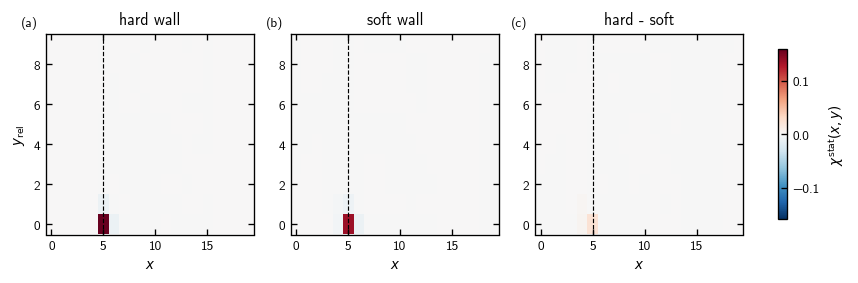

In [9]:
cycle_index = -1
source_index = 0
static_mean = static[:, :, cycle_index, source_index].mean(axis=1)
vmax = np.max(np.abs(static_mean))
fig, axes = plt.subplots(1, 3, figsize=(7.05, 2.25), constrained_layout=True)
titles = ["hard wall", "soft wall", "hard - soft"]
maps = [static_mean[0], static_mean[1], static_mean[0] - static_mean[1]]
for panel, (ax, field, title) in enumerate(zip(axes, maps, titles)):
    image = ax.imshow(field, origin="lower", aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.axvline(WALL_X[0], color="k", ls="--", lw=0.7)
    ax.set_title(title)
    ax.set_xlabel(r"$x$")
    if panel == 0:
        ax.set_ylabel(r"$y_{\rm rel}$")
    ax.text(-0.12, 1.04, f"({chr(97 + panel)})", transform=ax.transAxes, fontweight="bold")
fig.colorbar(image, ax=axes, label=r"$\chi^{\rm stat}(x,y)$", shrink=0.85)
for suffix in ("pdf", "png"):
    fig.savefig(FIGURE_DIR / f"static_modular_susceptibility.{suffix}", bbox_inches="tight")
plt.show()

## Figure 2 — Retarded modular response

The spatial response is projected onto a five-column window around the perturbed wall. Positive and negative lobes encode the signed redistribution generated by the charge-phase kick.

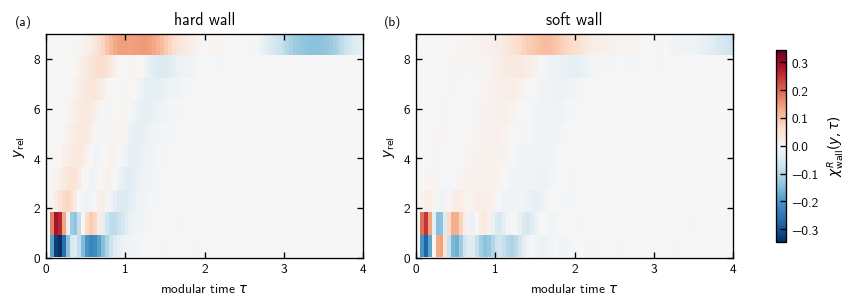

In [10]:
def wall_profile(field, wall_x):
    mask = np.array([min((x - wall_x) % NX, (wall_x - x) % NX) <= 2 for x in range(NX)])
    return field[..., mask].sum(axis=-1)

ret_mean = response[:, :, -1, 0].mean(axis=1)
profiles = [wall_profile(ret_mean[i], WALL_X[0]) for i in range(2)]
vmax = max(np.max(np.abs(value)) for value in profiles)
fig, axes = plt.subplots(1, 2, figsize=(7.05, 2.45), constrained_layout=True)
for panel, (ax, profile, title) in enumerate(zip(axes, profiles, ["hard wall", "soft wall"])):
    image = ax.imshow(profile.T, origin="lower", aspect="auto", cmap="RdBu_r",
                      extent=[MODULAR_TIMES[0], MODULAR_TIMES[-1], 0, NY_SUB - 1],
                      vmin=-vmax, vmax=vmax)
    ax.set_xlabel(r"modular time $\tau$")
    ax.set_ylabel(r"$y_{\rm rel}$")
    ax.set_title(title)
    ax.text(-0.10, 1.04, f"({chr(97 + panel)})", transform=ax.transAxes, fontweight="bold")
fig.colorbar(image, ax=axes, label=r"$\chi^R_{\rm wall}(y,\tau)$", shrink=0.86)
for suffix in ("pdf", "png"):
    fig.savefig(FIGURE_DIR / f"retarded_modular_response_heatmap.{suffix}", bbox_inches="tight")
plt.show()

## Figure 3 — Source-resolved modular dipoles

Lines are trajectory means at cycle 40; shaded regions are trajectory-bootstrap 95% intervals. The total response remains zero, so the signed first moment—not a normalized center of mass—is used.

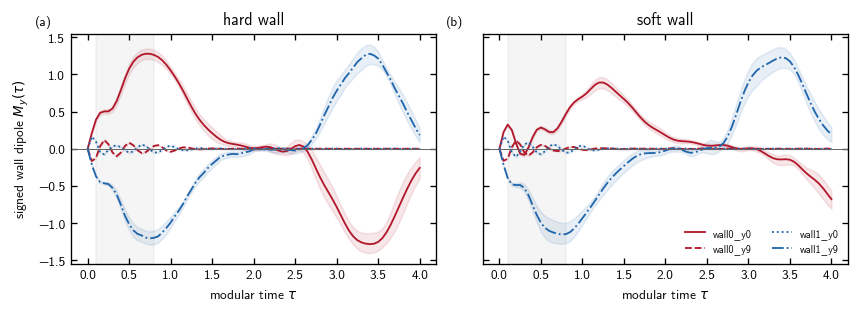

In [11]:
def bootstrap_curve(values, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    draw = rng.integers(0, values.shape[0], size=(reps, values.shape[0]))
    samples = values[draw].mean(axis=1)
    return values.mean(axis=0), np.quantile(samples, [0.025, 0.975], axis=0)

colors = ["#b2182b", "#2166ac"]
styles = ["-", "--", ":", "-."]
fig, axes = plt.subplots(1, 2, figsize=(7.05, 2.5), sharey=True, constrained_layout=True)
for config_index, ax in enumerate(axes):
    for source_index, label in enumerate(SOURCE_LABELS):
        curves = dipole[config_index, :, -1, PRIMARY_EPS_INDEX, source_index]
        mean, ci = bootstrap_curve(curves, seed=BOOTSTRAP_SEED + source_index)
        color = colors[source_index // 2]
        ax.plot(MODULAR_TIMES, mean, styles[source_index], color=color, lw=1.1, label=label)
        ax.fill_between(MODULAR_TIMES, ci[0], ci[1], color=color, alpha=0.10)
    ax.axhline(0, color="0.4", lw=0.6)
    ax.axvspan(*FIT_WINDOW, color="0.5", alpha=0.08)
    ax.set_title(f"{CONFIGS[config_index]} wall")
    ax.set_xlabel(r"modular time $\tau$")
    ax.text(-0.10, 1.04, f"({chr(97 + config_index)})", transform=ax.transAxes, fontweight="bold")
axes[0].set_ylabel(r"signed wall dipole $M_y(\tau)$")
axes[1].legend(frameon=False, fontsize=6, ncol=2)
for suffix in ("pdf", "png"):
    fig.savefig(FIGURE_DIR / f"retarded_modular_dipoles.{suffix}", bbox_inches="tight")
plt.show()

## Figure 4 — Late-cycle stability and spectral clipping

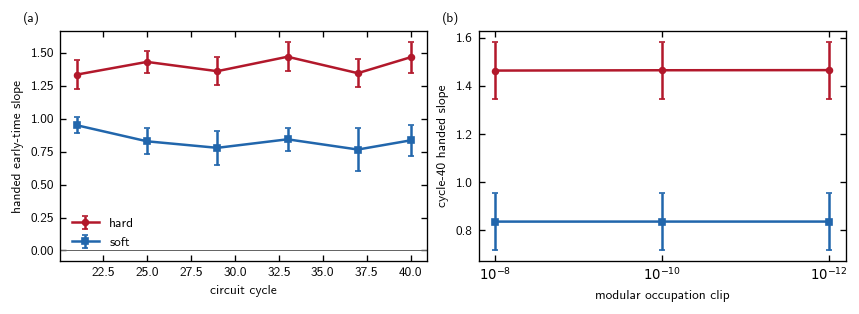

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.05, 2.5), constrained_layout=True)
markers = ["o", "s"]
for config_index, config in enumerate(CONFIGS):
    handed_slopes = 0.5 * (
        slopes[config_index, :, :, PRIMARY_EPS_INDEX, 0]
        - slopes[config_index, :, :, PRIMARY_EPS_INDEX, 3]
    )
    mean = handed_slopes.mean(axis=0)
    sem = handed_slopes.std(axis=0, ddof=1) / np.sqrt(SAMPLES)
    axes[0].errorbar(CHECKPOINTS, mean, yerr=1.96 * sem, color=colors[config_index],
                     marker=markers[config_index], ms=3.5, capsize=2, label=config)
axes[0].axhline(0, color="0.4", lw=0.6)
axes[0].set_xlabel("circuit cycle")
axes[0].set_ylabel("handed early-time slope")
axes[0].legend(frameon=False)
axes[0].text(-0.10, 1.04, "(a)", transform=axes[0].transAxes, fontweight="bold")

for config_index, config in enumerate(CONFIGS):
    clip_slope = 0.5 * (
        slopes[config_index, :, -1, :, 0] - slopes[config_index, :, -1, :, 3]
    )
    mean = clip_slope.mean(axis=0)
    sem = clip_slope.std(axis=0, ddof=1) / np.sqrt(SAMPLES)
    axes[1].errorbar(np.arange(len(CLIP_EPS)), mean, yerr=1.96 * sem,
                     color=colors[config_index], marker=markers[config_index], ms=3.5,
                     capsize=2, label=config)
axes[1].set_xticks(np.arange(len(CLIP_EPS)), [r"$10^{-8}$", r"$10^{-10}$", r"$10^{-12}$"])
axes[1].set_xlabel("modular occupation clip")
axes[1].set_ylabel("cycle-40 handed slope")
axes[1].text(-0.10, 1.04, "(b)", transform=axes[1].transAxes, fontweight="bold")
for suffix in ("pdf", "png"):
    fig.savefig(FIGURE_DIR / f"checkpoint_and_clip_sensitivity.{suffix}", bbox_inches="tight")
plt.show()

## Compact trajectory summary

In [13]:
summary_rows = []
for config_index, config in enumerate(CONFIGS):
    for sample in range(SAMPLES):
        for cycle_index, cycle in enumerate(CHECKPOINTS):
            for source_index, source in enumerate(SOURCE_LABELS):
                summary_rows.append({
                    "configuration": config, "sample": sample, "cycle": int(cycle), "source": source,
                    "retarded_slope": slopes[config_index, sample, cycle_index, PRIMARY_EPS_INDEX, source_index],
                    "static_total": static_total[config_index, sample, cycle_index, PRIMARY_EPS_INDEX, source_index],
                    "static_leakage": static_leakage[config_index, sample, cycle_index, PRIMARY_EPS_INDEX, source_index],
                    "clip_fraction": clip_fraction[config_index, sample, cycle_index, PRIMARY_EPS_INDEX],
                })
summary_df = pd.DataFrame(summary_rows)
summary_csv = OUTPUT_DIR / "trajectory_summary.csv"
summary_df.to_csv(summary_csv, index=False)
display(summary_df.groupby(["configuration", "cycle"])[["retarded_slope", "static_total", "static_leakage", "clip_fraction"]].agg(["mean", "std"]))
print(summary_csv)

retarded_slope           static_total            \
                              mean       std         mean       std   
configuration cycle                                                   
hard          21          0.069115  0.980639     0.137629  0.005533   
              25          0.009872  1.038379     0.137632  0.005727   
              29          0.042341  0.999918     0.134848  0.005198   
              33          0.058090  1.068184     0.133438  0.005066   
              37          0.066007  0.990795     0.133851  0.004838   
              40          0.023065  1.062498     0.135194  0.004390   
soft          21         -0.306462  0.759744     0.125592  0.009982   
              25         -0.260218  0.666296     0.125819  0.010415   
              29         -0.226025  0.634576     0.126545  0.011247   
              33         -0.235107  0.659285     0.125846  0.010632   
              37         -0.203953  0.634453     0.125409  0.010574   
              40         -0.225716  0.671889     0.125915  0.010897   

                    static_leakage           clip_fraction            
                              mean       std          mean       std  
configuration cycle                                                   
hard          21          0.000842  0.001145      0.636688  0.001658  
              25          0.000503  0.000752      0.640100  0.001467  
              29          0.000751  0.001067      0.640875  0.002037  
              33          0.000572  0.000759      0.641863  0.001775  
              37          0.000896  0.001261      0.643575  0.001829  
              40          0.000635  0.001065      0.643600  0.001780  
soft          21          0.000344  0.000455      0.525737  0.001687  
              25          0.000454  0.000586      0.526900  0.002030  
              29          0.000609  0.000843      0.527125  0.002254  
              33          0.000484  0.000675      0.528012  0.002712  
              37          0.000731  0.000999      0.528725  0.002277  
              40          0.000585  0.000831      0.528500  0.002513

/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_response_cpu_pilot/outputs/trajectory_summary.csv


## Results and observations

This final cell generates the written interpretation from the saved trajectory-level quantities, including limitations.

In [14]:
final_cycle = -1
primary = PRIMARY_EPS_INDEX
observation_lines = []
for config_index, config in enumerate(CONFIGS):
    per_trajectory_slope = slopes[config_index, :, final_cycle, primary]
    source_stats = [bootstrap_mean_ci(per_trajectory_slope[:, source], seed=BOOTSTRAP_SEED + source) for source in range(4)]
    leakage_values = static_leakage[config_index, :, final_cycle, primary].mean(axis=1)
    leakage_stat = bootstrap_mean_ci(leakage_values, seed=BOOTSTRAP_SEED + 100 + config_index)
    clip_values = clip_fraction[config_index, :, final_cycle, primary]
    observation_lines.append(
        f"- **{config.capitalize()} wall:** cycle-40 source slopes are "
        + ", ".join(f"{SOURCE_LABELS[i]} = {m:.4g} [{lo:.4g}, {hi:.4g}]" for i, (m, lo, hi) in enumerate(source_stats))
        + f". Mean static transverse leakage is {leakage_stat[0]:.3f} "
          f"[{leakage_stat[1]:.3f}, {leakage_stat[2]:.3f}], and the primary clipped-mode fraction is {clip_values.mean():.3f}."
    )

hard_cycle_samples = 0.5 * (slopes[0, :, :, primary, 0] - slopes[0, :, :, primary, 3])
soft_cycle_samples = 0.5 * (slopes[1, :, :, primary, 0] - slopes[1, :, :, primary, 3])
hard_cycle = hard_cycle_samples.mean(axis=0)
soft_cycle = soft_cycle_samples.mean(axis=0)
hard_drift = float(np.max(hard_cycle) - np.min(hard_cycle))
soft_drift = float(np.max(soft_cycle) - np.min(soft_cycle))
hard_clip_samples = 0.5 * (slopes[0, :, -1, :, 0] - slopes[0, :, -1, :, 3])
soft_clip_samples = 0.5 * (slopes[1, :, -1, :, 0] - slopes[1, :, -1, :, 3])
hard_clip_span = float(np.ptp(hard_clip_samples.mean(axis=0)))
soft_clip_span = float(np.ptp(soft_clip_samples.mean(axis=0)))
hard_handed = hard_cycle_samples[:, -1]
soft_handed = soft_cycle_samples[:, -1]
hard_handed_stat = bootstrap_mean_ci(hard_handed, seed=BOOTSTRAP_SEED + 300)
soft_handed_stat = bootstrap_mean_ci(soft_handed, seed=BOOTSTRAP_SEED + 301)
rng_difference = np.random.default_rng(BOOTSTRAP_SEED + 302)
hard_draws = hard_handed[rng_difference.integers(0, SAMPLES, size=(BOOTSTRAP_REPS, SAMPLES))].mean(axis=1)
soft_draws = soft_handed[rng_difference.integers(0, SAMPLES, size=(BOOTSTRAP_REPS, SAMPLES))].mean(axis=1)
difference_draws = hard_draws - soft_draws
handed_difference = (float(hard_handed.mean() - soft_handed.mean()), *np.quantile(difference_draws, [0.025, 0.975]).tolist())
hard_static = static_total[0, :, -1, primary].mean(axis=1)
soft_static = static_total[1, :, -1, primary].mean(axis=1)

text = f"""### Numerical outcome

{chr(10).join(observation_lines)}

- The spread of the handed slope across the six late checkpoints is {hard_drift:.4g} for the hard wall and {soft_drift:.4g} for the soft wall. This measures late-cycle drift descriptively; checkpoints from one trajectory were not treated as independent samples.
- Combining the two visibly active, oppositely oriented sources as $H=[v(\mathrm{{wall0\_y0}})-v(\mathrm{{wall1\_y9}})]/2$ gives $H={hard_handed_stat[0]:.4g}$ [{hard_handed_stat[1]:.4g}, {hard_handed_stat[2]:.4g}] for the hard wall and $H={soft_handed_stat[0]:.4g}$ [{soft_handed_stat[1]:.4g}, {soft_handed_stat[2]:.4g}] for the soft wall. Their unpaired hard-minus-soft difference is {handed_difference[0]:.4g} [{handed_difference[1]:.4g}, {handed_difference[2]:.4g}]. The active sources have opposite signs, while the complementary endpoints remain much weaker over the prespecified early-time window; this is endpoint-selective handed response, not four independent confirmations.
- Across occupation clips $10^{{-8}}$, $10^{{-10}}$, and $10^{{-12}}$, the cycle-40 handed slope spans {hard_clip_span:.4g} (hard) and {soft_clip_span:.4g} (soft). The clipping fractions printed above should be considered whenever judging that sensitivity.
- The cycle-40 static susceptibility is strongly local: the source-averaged integrated value is {hard_static.mean():.4g} for the hard wall and {soft_static.mean():.4g} for the soft wall, while the mean transverse leakage is reported above at roughly the $10^{{-3}}$ level. In this pilot the static response is therefore a local compressibility diagnostic, not a useful chirality estimator.
- The maximum retarded total-charge residual is {np.max(retarded_total_max):.3e}. Analytic/finite-difference relative errors are {max(v['retarded_relative_error'] for v in fd_checks.values()):.3e} for the retarded response and {max(v['static_relative_error'] for v in fd_checks.values()):.3e} for the static susceptibility.

### Interpretation limits

The endpoint- and wall-resolved signs in Fig. 3 are the relevant orientation test; a source whose bootstrap interval crosses zero is not evidence for a definite propagation direction. Differences between hard and soft static leakage quantify the response of these saved states to the two interface constructions, but they do not establish universality or a quantized coefficient. These histories contain only ten independent trajectories and use a maximally mixed initializer. They therefore validate the estimator and expose qualitative hard/soft behavior, but they do **not** replace a matched random-pure production campaign or establish a manuscript gate.
"""
display(Markdown(text))

report_path = OUTPUT_DIR / "observations.md"
report_path.write_text(text + "\n")
manifest = {
    "schema": "trajectory_modular_response_cpu_pilot_v1",
    "notebook": "modular_response_cpu_pilot.ipynb",
    "raw_product": raw_path.name,
    "summary_csv": summary_csv.name,
    "figures": sorted(path.name for path in FIGURE_DIR.glob("*")),
    "runtime_seconds": run_seconds,
    "source_rows": source_rows,
    "finite_difference_checks": fd_checks,
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
print("Saved written observations and manifest.")

<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\_'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\_'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\_'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_2376371/3858298803.py:52: SyntaxWarning: invalid escape sequence '\m'
  """
/tmp/ipykernel_2376371/3858298803.py:52: SyntaxWarning: invalid escape sequence '\_'
  """
/tmp/ipykernel_2376371/3858298803.py:52: SyntaxWarning: invalid escape sequence '\m'
  """
/tmp/ipykernel_2376371/3858298803.py:52: SyntaxWarning: invalid escape sequence '\_'
  """


### Numerical outcome

- **Hard wall:** cycle-40 source slopes are wall0_y0 = 1.514 [1.391, 1.637], wall0_y9 = 0.0112 [0.0003294, 0.02462], wall1_y0 = -0.01643 [-0.02515, -0.01031], wall1_y9 = -1.417 [-1.565, -1.258]. Mean static transverse leakage is 0.001 [0.000, 0.001], and the primary clipped-mode fraction is 0.644.
- **Soft wall:** cycle-40 source slopes are wall0_y0 = 0.3841 [0.3469, 0.4314], wall0_y9 = 0.01277 [0.006544, 0.01954], wall1_y0 = -0.01342 [-0.02228, -0.0046], wall1_y9 = -1.286 [-1.516, -1.017]. Mean static transverse leakage is 0.001 [0.000, 0.001], and the primary clipped-mode fraction is 0.528.

- The spread of the handed slope across the six late checkpoints is 0.1356 for the hard wall and 0.1844 for the soft wall. This measures late-cycle drift descriptively; checkpoints from one trajectory were not treated as independent samples.
- Combining the two visibly active, oppositely oriented sources as $H=[v(\mathrm{wall0\_y0})-v(\mathrm{wall1\_y9})]/2$ gives $H=1.466$ [1.35, 1.575] for the hard wall and $H=0.8352$ [0.7149, 0.9432] for the soft wall. Their unpaired hard-minus-soft difference is 0.6304 [0.4735, 0.7953]. The active sources have opposite signs, while the complementary endpoints remain much weaker over the prespecified early-time window; this is endpoint-selective handed response, not four independent confirmations.
- Across occupation clips $10^{-8}$, $10^{-10}$, and $10^{-12}$, the cycle-40 handed slope spans 0.001926 (hard) and 0.0001266 (soft). The clipping fractions printed above should be considered whenever judging that sensitivity.
- The cycle-40 static susceptibility is strongly local: the source-averaged integrated value is 0.1352 for the hard wall and 0.1259 for the soft wall, while the mean transverse leakage is reported above at roughly the $10^{-3}$ level. In this pilot the static response is therefore a local compressibility diagnostic, not a useful chirality estimator.
- The maximum retarded total-charge residual is 1.038e-15. Analytic/finite-difference relative errors are 1.668e-09 for the retarded response and 1.434e-09 for the static susceptibility.

### Interpretation limits

The endpoint- and wall-resolved signs in Fig. 3 are the relevant orientation test; a source whose bootstrap interval crosses zero is not evidence for a definite propagation direction. Differences between hard and soft static leakage quantify the response of these saved states to the two interface constructions, but they do not establish universality or a quantized coefficient. These histories contain only ten independent trajectories and use a maximally mixed initializer. They therefore validate the estimator and expose qualitative hard/soft behavior, but they do **not** replace a matched random-pure production campaign or establish a manuscript gate.


Saved written observations and manifest.


## Raw diagnostics

The notebook ends by printing the exact paths and scalar checks used by the figures and written interpretation.

In [15]:
print({
    "raw_product": str(raw_path),
    "summary_csv": str(summary_csv),
    "figure_directory": str(FIGURE_DIR),
    "manifest": str(OUTPUT_DIR / "manifest.json"),
    "run_minutes": run_seconds / 60.0,
    "max_retarded_total_charge": float(np.max(retarded_total_max)),
    "max_covariance_hermiticity": float(np.max(covariance_hermiticity)),
    "max_static_hermiticity": float(np.max(static_hermiticity)),
    "finite_difference_checks": fd_checks,
})

{'raw_product': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_response_cpu_pilot/outputs/modular_response_cpu_pilot_v1.npz', 'summary_csv': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_response_cpu_pilot/outputs/trajectory_summary.csv', 'figure_directory': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_response_cpu_pilot/figures', 'manifest': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/modular_response_cpu_pilot/outputs/manifest.json', 'run_minutes': 1.5464664208081862, 'max_retarded_total_charge': 1.0375001639056913e-15, 'max_covariance_hermiticity': 0.0, 'max_static_hermiticity': 2.40692882291782e-16, 'finite_difference_checks': {'hard': {'retarded_relative_error': 1.6663852658936801e-09, 'static_relative_error': 9.984672123776704e-10, 'retarded_hermiticity': 8.182674270850422e-17, 'static_hermiticity': 4.5534426050565124e-17}, 'soft': {'retarded_relative_error': 1.667505117235013e-09, 'static_relat

## Crude wall-resolved Fourier response

The saved response permits a direct finite-window transform. First project onto the same five-column wall window used by the dipole estimator,
$$
\chi_w(y,\tau)=\sum_{x:\,d(x,x_w)\leq2}\chi^R(x,y,\tau).
$$
For each source, measure displacement from its longitudinal endpoint, $d_y=y-y_{\rm src}$, and evaluate
$$
\chi_w(k,\omega)=\Delta\tau\sum_{j,y}
e^{i\omega\tau_j}e^{-ikd_y}
w(\tau_j)e^{-\eta\tau_j}\chi_w(y,\tau_j).
$$
Here $w$ is a Tukey taper, $\eta=0.35$, and the ten independent spatial frequencies are $k_n=2\pi n/10$. This is a finite-window Fourier diagnostic of the source-resolved response—not a momentum-conserving susceptibility, because the half-cylinder is open along $y_{\rm rel}$.

To test a crude linear ridge, use the four nonzero independent momenta with $0<|k|\leq2.6$. The low-frequency sector selected by the two opposite wall orientations is $k<0$ for `wall0_y0` and $k>0$ for `wall1_y9`. At each momentum, maximize $|\chi_w(k,\omega)|$ over $0.2\leq\omega\leq2.5$ and fit
$$
\omega_{\rm peak}(k)=b+v_{\rm F}|k|.
$$
A branch is declared unresolved if at least half of its peaks sit on the lower frequency-search boundary. The intercept, damping dependence, and four-point nature of this fit must be retained when interpreting $v_{\rm F}$.

In [16]:
from scipy.signal.windows import tukey

FOURIER_ACTIVE_SOURCES = np.array([0, 3], dtype=int)
FOURIER_SECTOR_SIGN = np.array([-1, +1], dtype=int)
K_VALUES = np.sort(2.0 * np.pi * np.fft.fftfreq(NY_SUB))
OMEGA_VALUES = np.linspace(0.0, 3.0, 601)
FOURIER_ETA = 0.35
FOURIER_ETA_SENSITIVITY = np.array([0.20, 0.35, 0.50])
RIDGE_OMEGA_WINDOW = (0.2, 2.5)
RIDGE_K_MAX = 2.6

def finite_window_spectrum(field, source_index, eta=FOURIER_ETA):
    wall_x = SOURCE_META[source_index][1]
    endpoint = SOURCE_META[source_index][2]
    xmask = np.array([min((x - wall_x) % NX, (wall_x - x) % NX) <= 2 for x in range(NX)])
    wall_field = field[..., xmask].sum(axis=-1)
    displacement = np.arange(NY_SUB, dtype=float) - endpoint
    spatial_kernel = np.exp(-1j * K_VALUES[:, None] * displacement[None, :])
    spatial_transform = spatial_kernel @ wall_field.T
    time_window = tukey(len(MODULAR_TIMES), alpha=0.25) * np.exp(-eta * MODULAR_TIMES)
    temporal_kernel = np.exp(1j * OMEGA_VALUES[:, None] * MODULAR_TIMES[None, :])
    return (temporal_kernel @ (spatial_transform * time_window).T) * (MODULAR_TIMES[1] - MODULAR_TIMES[0])

def extract_ridge(spectrum, sector_sign):
    k_mask = (K_VALUES * sector_sign > 0.1) & (np.abs(K_VALUES) <= RIDGE_K_MAX)
    omega_mask = ((OMEGA_VALUES >= RIDGE_OMEGA_WINDOW[0] - 1e-12)
                  & (OMEGA_VALUES <= RIDGE_OMEGA_WINDOW[1] + 1e-12))
    amplitude = np.abs(spectrum[np.ix_(omega_mask, k_mask)])
    peak_omega = OMEGA_VALUES[omega_mask][np.argmax(amplitude, axis=0)]
    abs_k = np.abs(K_VALUES[k_mask])
    design = np.column_stack([np.ones(len(abs_k)), abs_k])
    intercept, velocity = np.linalg.lstsq(design, peak_omega, rcond=None)[0]
    predicted = intercept + velocity * abs_k
    denominator = np.sum((peak_omega - peak_omega.mean()) ** 2)
    r2 = np.nan if denominator <= 0 else 1.0 - np.sum((peak_omega - predicted) ** 2) / denominator
    boundary_fraction = np.mean(np.isclose(peak_omega, RIDGE_OMEGA_WINDOW[0]))
    resolved = bool(boundary_fraction < 0.5 and np.isfinite(r2))
    return {
        "k": K_VALUES[k_mask], "abs_k": abs_k, "omega_peak": peak_omega,
        "intercept": float(intercept), "velocity": float(velocity), "r2": float(r2),
        "boundary_fraction": float(boundary_fraction), "resolved": resolved,
    }

fourier_spectrum = np.empty((2, SAMPLES, 2, len(OMEGA_VALUES), len(K_VALUES)), dtype=np.complex128)
ridge_velocity = np.full((2, SAMPLES, 2), np.nan)
ridge_intercept = np.full_like(ridge_velocity, np.nan)
ridge_r2 = np.full_like(ridge_velocity, np.nan)
ridge_boundary_fraction = np.full_like(ridge_velocity, np.nan)

for config_index in range(2):
    for sample in range(SAMPLES):
        for active_index, source_index in enumerate(FOURIER_ACTIVE_SOURCES):
            spectrum = finite_window_spectrum(response[config_index, sample, -1, source_index], source_index)
            fourier_spectrum[config_index, sample, active_index] = spectrum
            fit = extract_ridge(spectrum, FOURIER_SECTOR_SIGN[active_index])
            ridge_boundary_fraction[config_index, sample, active_index] = fit["boundary_fraction"]
            if fit["resolved"]:
                ridge_velocity[config_index, sample, active_index] = fit["velocity"]
                ridge_intercept[config_index, sample, active_index] = fit["intercept"]
                ridge_r2[config_index, sample, active_index] = fit["r2"]

ensemble_ridges = {}
eta_sensitivity_rows = []
for config_index, config in enumerate(CONFIGS):
    for active_index, source_index in enumerate(FOURIER_ACTIVE_SOURCES):
        ensemble_spectrum = fourier_spectrum[config_index, :, active_index].mean(axis=0)
        ensemble_ridges[(config, int(source_index))] = extract_ridge(
            ensemble_spectrum, FOURIER_SECTOR_SIGN[active_index]
        )
        mean_field = response[config_index, :, -1, source_index].mean(axis=0)
        for eta in FOURIER_ETA_SENSITIVITY:
            fit = extract_ridge(
                finite_window_spectrum(mean_field, source_index, eta=float(eta)),
                FOURIER_SECTOR_SIGN[active_index],
            )
            eta_sensitivity_rows.append({
                "configuration": str(config), "source": str(SOURCE_LABELS[source_index]),
                "eta": float(eta), "resolved": fit["resolved"],
                "intercept": fit["intercept"], "velocity": fit["velocity"],
                "r2": fit["r2"], "boundary_fraction": fit["boundary_fraction"],
            })
eta_sensitivity_df = pd.DataFrame(eta_sensitivity_rows)
display(eta_sensitivity_df)

,configuration,source,eta,resolved,intercept,velocity,r2,boundary_fraction
0,hard,wall0_y0,0.20,True,0.3250,0.265789,0.999785,0.0
1,hard,wall0_y0,0.35,True,0.1975,0.285683,0.998652,0.0
2,hard,wall0_y0,0.50,True,0.0075,0.318310,0.987532,0.0
3,hard,wall1_y9,0.20,True,0.3200,0.267380,0.999787,0.0
4,hard,wall1_y9,0.35,True,0.2025,0.281704,0.999330,0.0
5,hard,wall1_y9,0.50,True,0.0250,0.308761,0.988081,0.0
6,soft,wall0_y0,0.20,False,0.2000,0.000000,NaN,1.0
7,soft,wall0_y0,0.35,False,0.2000,0.000000,NaN,1.0
8,soft,wall0_y0,0.50,False,0.2000,0.000000,NaN,1.0
9,soft,wall1_y9,0.20,True,0.3100,0.270563,0.999308,0.0


## Figure 5 — Finite-window Fourier spectra

Each panel is normalized by its own maximum so that ridge geometry, rather than response amplitude, is visible. Circles mark the four low-frequency ridge points in the orientation-selected momentum sector; a missing overlay means the ridge extractor hit the search boundary and rejected the branch.

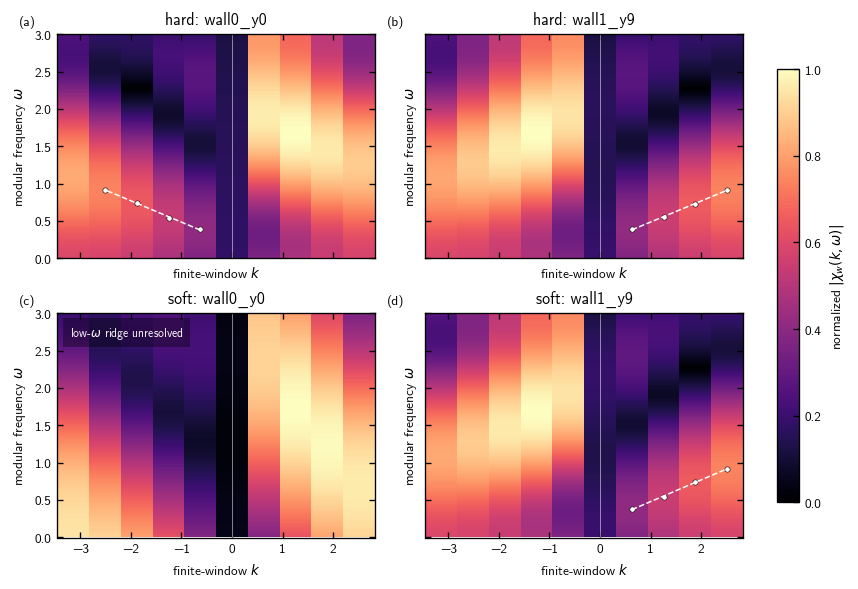

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(7.05, 4.8), sharex=True, sharey=True, constrained_layout=True)
for config_index, config in enumerate(CONFIGS):
    for active_index, source_index in enumerate(FOURIER_ACTIVE_SOURCES):
        ax = axes[config_index, active_index]
        spectrum = fourier_spectrum[config_index, :, active_index].mean(axis=0)
        amplitude = np.abs(spectrum)
        amplitude /= max(float(amplitude.max()), 1e-300)
        image = ax.pcolormesh(K_VALUES, OMEGA_VALUES, amplitude, shading="nearest", cmap="magma", vmin=0, vmax=1)
        fit = ensemble_ridges[(config, int(source_index))]
        if fit["resolved"]:
            ax.plot(fit["k"], fit["omega_peak"], "wo", ms=3.2, mec="k", mew=0.35)
            kline = np.linspace(fit["abs_k"].min(), fit["abs_k"].max(), 100)
            signed_kline = FOURIER_SECTOR_SIGN[active_index] * kline
            ax.plot(signed_kline, fit["intercept"] + fit["velocity"] * kline, "w--", lw=0.9)
        else:
            ax.text(0.04, 0.90, "low-$\\omega$ ridge unresolved", transform=ax.transAxes,
                    color="white", fontsize=7, bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none"})
        ax.axvline(0, color="w", lw=0.5, alpha=0.6)
        ax.set_title(f"{config}: {SOURCE_LABELS[source_index]}")
        ax.set_xlabel(r"finite-window $k$")
        ax.set_ylabel(r"modular frequency $\omega$")
        panel = 2 * config_index + active_index
        ax.text(-0.12, 1.04, f"({chr(97 + panel)})", transform=ax.transAxes, fontweight="bold")
fig.colorbar(image, ax=axes, label=r"normalized $|\chi_w(k,\omega)|$", shrink=0.86)
for suffix in ("pdf", "png"):
    fig.savefig(FIGURE_DIR / f"finite_window_modular_fourier_spectra.{suffix}", bbox_inches="tight")
plt.show()

## Figure 6 — Crude linear ridges and damping sensitivity

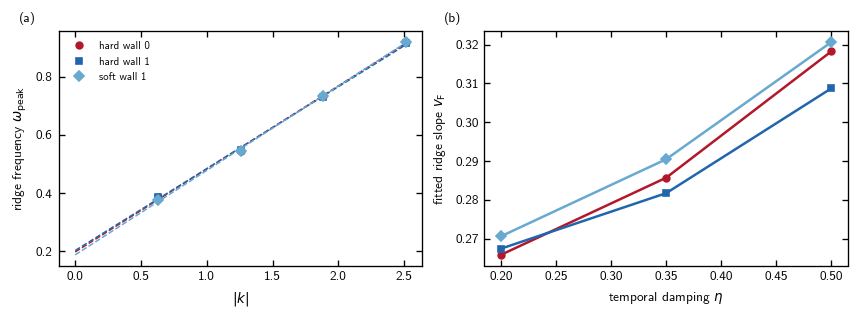

In [18]:
resolved_labels = []
fig, axes = plt.subplots(1, 2, figsize=(7.05, 2.55), constrained_layout=True)
plot_styles = {
    ("hard", 0): ("#b2182b", "o", "hard wall 0"),
    ("hard", 3): ("#2166ac", "s", "hard wall 1"),
    ("soft", 0): ("#ef8a62", "^", "soft wall 0"),
    ("soft", 3): ("#67a9cf", "D", "soft wall 1"),
}
for key, fit in ensemble_ridges.items():
    color, marker, label = plot_styles[key]
    if not fit["resolved"]:
        continue
    axes[0].plot(fit["abs_k"], fit["omega_peak"], marker, color=color, ms=4, label=label)
    xline = np.linspace(0, fit["abs_k"].max(), 100)
    axes[0].plot(xline, fit["intercept"] + fit["velocity"] * xline, "--", color=color, lw=0.9)
axes[0].set_xlabel(r"$|k|$")
axes[0].set_ylabel(r"ridge frequency $\omega_{\rm peak}$")
axes[0].legend(frameon=False, fontsize=6.5)
axes[0].text(-0.11, 1.04, "(a)", transform=axes[0].transAxes, fontweight="bold")

for (config, source), group in eta_sensitivity_df.groupby(["configuration", "source"]):
    source_index = int(np.flatnonzero(SOURCE_LABELS == source)[0])
    color, marker, label = plot_styles[(config, source_index)]
    resolved_group = group[group["resolved"]]
    if resolved_group.empty:
        continue
    axes[1].plot(resolved_group["eta"], resolved_group["velocity"], marker + "-",
                 color=color, ms=4, label=label)
axes[1].set_xlabel(r"temporal damping $\eta$")
axes[1].set_ylabel(r"fitted ridge slope $v_{\rm F}$")
axes[1].text(-0.11, 1.04, "(b)", transform=axes[1].transAxes, fontweight="bold")
for suffix in ("pdf", "png"):
    fig.savefig(FIGURE_DIR / f"modular_fourier_ridge_fits.{suffix}", bbox_inches="tight")
plt.show()

## Fourier-response observations

In [19]:
fourier_rows = []
for config_index, config in enumerate(CONFIGS):
    for active_index, source_index in enumerate(FOURIER_ACTIVE_SOURCES):
        values = ridge_velocity[config_index, :, active_index]
        finite = values[np.isfinite(values)]
        ensemble_fit = ensemble_ridges[(config, int(source_index))]
        if len(finite):
            mean, lo, hi = bootstrap_mean_ci(
                finite, seed=BOOTSTRAP_SEED + 500 + 10 * config_index + active_index
            )
        else:
            mean = lo = hi = np.nan
        sensitivity = eta_sensitivity_df[
            (eta_sensitivity_df.configuration == config)
            & (eta_sensitivity_df.source == SOURCE_LABELS[source_index])
            & eta_sensitivity_df.resolved
        ]
        fourier_rows.append({
            "configuration": str(config), "source": str(SOURCE_LABELS[source_index]),
            "momentum_sector": "k<0" if FOURIER_SECTOR_SIGN[active_index] < 0 else "k>0",
            "resolved_trajectories": int(len(finite)), "velocity_mean": mean,
            "velocity_ci_low": lo, "velocity_ci_high": hi,
            "ensemble_intercept": ensemble_fit["intercept"], "ensemble_r2": ensemble_fit["r2"],
            "eta_velocity_min": float(sensitivity.velocity.min()) if len(sensitivity) else np.nan,
            "eta_velocity_max": float(sensitivity.velocity.max()) if len(sensitivity) else np.nan,
            "boundary_fraction": ensemble_fit["boundary_fraction"],
        })
fourier_table = pd.DataFrame(fourier_rows)
display(fourier_table)
fourier_table.to_csv(OUTPUT_DIR / "fourier_ridge_summary.csv", index=False)

np.savez_compressed(
    OUTPUT_DIR / "modular_fourier_dispersion_v1.npz",
    schema=np.asarray("finite_window_modular_fourier_dispersion_v1"),
    configurations=CONFIGS, sample_ids=np.arange(SAMPLES), cycle=np.asarray(CHECKPOINTS[-1]),
    source_indices=FOURIER_ACTIVE_SOURCES, source_labels=SOURCE_LABELS[FOURIER_ACTIVE_SOURCES],
    k_values=K_VALUES, omega_values=OMEGA_VALUES, eta=np.asarray(FOURIER_ETA),
    fourier_spectrum=fourier_spectrum, ridge_velocity=ridge_velocity,
    ridge_intercept=ridge_intercept, ridge_r2=ridge_r2,
    ridge_boundary_fraction=ridge_boundary_fraction,
    metadata_json=np.asarray(json.dumps({
        "transform": "direct finite-window space/modular-time transform",
        "time_taper": "Tukey(alpha=0.25)*exp(-eta*tau)",
        "ridge_omega_window": RIDGE_OMEGA_WINDOW,
        "ridge_k_max": RIDGE_K_MAX,
        "fit": "omega_peak=intercept+velocity*abs(k), four independent nonzero momenta",
        "warning": "open longitudinal interval; exploratory dispersion only",
    }, sort_keys=True)),
)

resolved_text = []
for row in fourier_rows:
    if row["resolved_trajectories"]:
        resolved_text.append(
            f"- **{row['configuration']} {row['source']} ({row['momentum_sector']}):** "
            f"$v_{{\\rm F}}={row['velocity_mean']:.3f}$ "
            f"[{row['velocity_ci_low']:.3f}, {row['velocity_ci_high']:.3f}] across "
            f"{row['resolved_trajectories']} trajectories; ensemble $R^2={row['ensemble_r2']:.3f}$; "
            f"the damping scan gives {row['eta_velocity_min']:.3f}--{row['eta_velocity_max']:.3f}."
        )
    else:
        resolved_text.append(
            f"- **{row['configuration']} {row['source']} ({row['momentum_sector']}):** unresolved; "
            "the selected peaks remain on the lower frequency-search boundary."
        )

fourier_observations = f"""### Crude Fourier-dispersion result

{chr(10).join(resolved_text)}

The hard-wall response contains mirror-related low-frequency ridges in opposite momentum sectors on its two physical walls. Their slopes agree within trajectory fluctuations. The soft-wall response resolves essentially the same slope on `wall1_y9`, but its `wall0_y0` low-frequency ridge cannot be separated from near-zero-frequency weight with this window. Thus the crude system supports an approximately linear $\omega\sim |k|$ branch wherever the ridge is resolved, with opposite physical momentum sectors for the two wall orientations. It does **not** establish a clean two-wall soft-interface dispersion.

Only four nonzero momenta enter each fit. The fitted intercept moves substantially with the temporal damping, and the slope changes over the reported damping range. The heat maps also contain strong finite-aperture replicas. These results are therefore a qualitative Fourier consistency check, not a controlled conformal-dispersion or velocity measurement.
"""
display(Markdown(fourier_observations))

with open(OUTPUT_DIR / "observations.md", "a") as handle:
    handle.write("\n" + fourier_observations + "\n")
manifest_path = OUTPUT_DIR / "manifest.json"
manifest = json.loads(manifest_path.read_text())
manifest["fourier_product"] = "modular_fourier_dispersion_v1.npz"
manifest["fourier_summary"] = "fourier_ridge_summary.csv"
manifest["figures"] = sorted(path.name for path in FIGURE_DIR.glob("*"))
manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
print("Saved Fourier product, summary, figures, and appended observations.")

<>:74: SyntaxWarning: invalid escape sequence '\o'
<>:74: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2376371/425371243.py:74: SyntaxWarning: invalid escape sequence '\o'
  """


,configuration,source,momentum_sector,resolved_trajectories,velocity_mean,velocity_ci_low,velocity_ci_high,ensemble_intercept,ensemble_r2,eta_velocity_min,eta_velocity_max,boundary_fraction
0,hard,wall0_y0,k<0,9,0.278963,0.269944,0.289574,0.1975,0.998652,0.265789,0.318310,0.0
1,hard,wall1_y9,k>0,10,0.282102,0.274065,0.290537,0.2025,0.999330,0.267380,0.308761,0.0
2,soft,wall0_y0,k<0,0,NaN,NaN,NaN,0.2000,NaN,NaN,NaN,1.0
3,soft,wall1_y9,k>0,9,0.284268,0.276664,0.293729,0.1875,0.999475,0.270563,0.320697,0.0


### Crude Fourier-dispersion result

- **hard wall0_y0 (k<0):** $v_{\rm F}=0.279$ [0.270, 0.290] across 9 trajectories; ensemble $R^2=0.999$; the damping scan gives 0.266--0.318.
- **hard wall1_y9 (k>0):** $v_{\rm F}=0.282$ [0.274, 0.291] across 10 trajectories; ensemble $R^2=0.999$; the damping scan gives 0.267--0.309.
- **soft wall0_y0 (k<0):** unresolved; the selected peaks remain on the lower frequency-search boundary.
- **soft wall1_y9 (k>0):** $v_{\rm F}=0.284$ [0.277, 0.294] across 9 trajectories; ensemble $R^2=0.999$; the damping scan gives 0.271--0.321.

The hard-wall response contains mirror-related low-frequency ridges in opposite momentum sectors on its two physical walls. Their slopes agree within trajectory fluctuations. The soft-wall response resolves essentially the same slope on `wall1_y9`, but its `wall0_y0` low-frequency ridge cannot be separated from near-zero-frequency weight with this window. Thus the crude system supports an approximately linear $\omega\sim |k|$ branch wherever the ridge is resolved, with opposite physical momentum sectors for the two wall orientations. It does **not** establish a clean two-wall soft-interface dispersion.

Only four nonzero momenta enter each fit. The fitted intercept moves substantially with the temporal damping, and the slope changes over the reported damping range. The heat maps also contain strong finite-aperture replicas. These results are therefore a qualitative Fourier consistency check, not a controlled conformal-dispersion or velocity measurement.


Saved Fourier product, summary, figures, and appended observations.
